# Initial setups

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# prompt: generate the code to change the current working directory to main directory

import os
# Check the current working directory
print(os.getcwd())

# Change the current working directory
os.chdir('/content/drive/MyDrive/Complete Machine Learning') # Write the current working directory as parameter

# List contents of the main directory (root directory)
!ls

/content
 Data		 'Data Preprocessing'   Numpy.ipynb
'Data Analysis'  'Gathering the Data'  'Python introduction.ipynb'


In [3]:
AB_NYC = pd.read_csv('Data/AB_NYC_2019.csv')

# Correcting DataType
AB_NYC["id"] = AB_NYC["id"].astype(str)
AB_NYC["host_id"] = AB_NYC["host_id"].astype(str)
AB_NYC["latitude"] = AB_NYC["latitude"].astype(str)
AB_NYC["longitude"] = AB_NYC["longitude"].astype(str)

# Null Values & Duplicates
# AB_NYC = AB_NYC.drop_duplicates(keep='last',ignore_index=True)
# AB_NYC = AB_NYC.dropna()

# Univariate Analysis
Analyzing & Summarizing of one column at a time to understand its behavior. The main goal is to summarize and find patterns in that single column of data.
It does not look at relationships between two or more variables (that’s bivariate or multivariate analysis).
## Why?
1. To understand the **distribution** of data.
2. To check for **outliers** (extreme values).
3. To know the **central tendency** (mean, median, mode).
4. To see the **spread** (variance, standard deviation, range).
5. To choose the **right statistical method** for further analysis.

# **Categorical Analysis**
 In the context of categorical data, univariate visualizations help us better understand the frequency distribution of different categories. Two commonly used visualizations for categorical data are **bar graphs** and **pie charts**.

1. **Frequency counts**
2. **Proportions / Percentages**
3. **Visualization:** bar charts, pie charts

## Bar Graph  
A visual representation that uses rectangular bars to show the frequency or value of different categories, making comparisons easy.  

With Seaborn's `countplot()`, we can easily create bar plots to visualize the distribution of categorical variables.  
```
sns.countplot(data=None, x=None, y=None, hue=None, order=None, orient=None, color=None, palette=None)
```
* **data** (default = None, optional) → Dataset (like DataFrame) from which variables are taken.  
* **x** (default = None, optional) → The column name you want to show on the horizontal axis.  
* **y** (default = None, optional) → The column name you want to show on the vertical axis  
* **hue** (default = None, optional) → Another column name to divide each bar into colors for subcategories.  

<Axes: xlabel='neighbourhood_group', ylabel='count'>

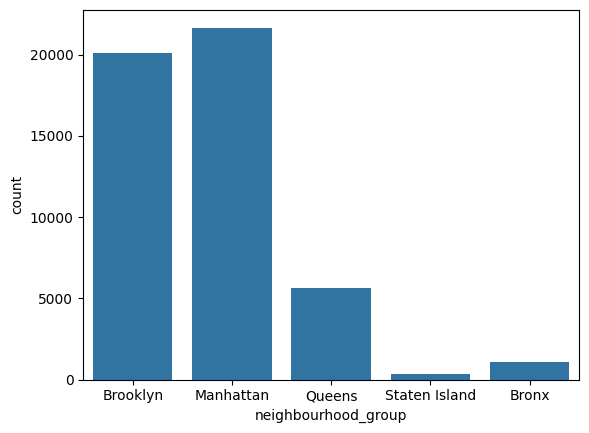

In [4]:
sns.countplot(x="neighbourhood_group", data=AB_NYC)

The distribution of room types within each neighborhood group:

<Axes: xlabel='neighbourhood_group', ylabel='count'>

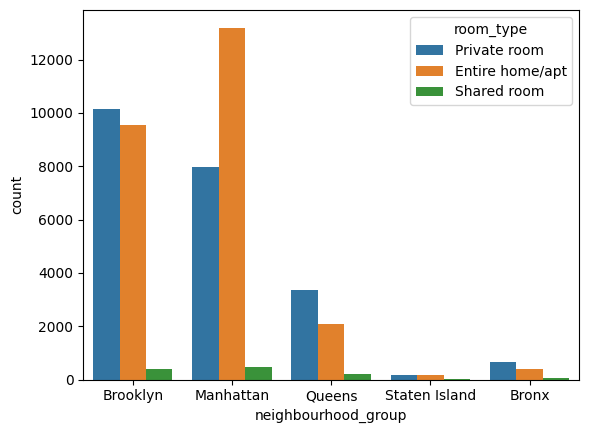

In [5]:
sns.countplot(data=AB_NYC, x="neighbourhood_group", hue="room_type")

## Pie Chart
 A circular chart divided into slices, where each slice represents a category’s proportion relative to the whole.  
 `value_counts().plot(kind ='')` kind may contain `'pie', 'hist', 'box', 'bar'`. & `.plot(autopct="%.2f`)` can give percentages in Pie chart.

In [6]:
AB_NYC["room_type"].value_counts()

,count
room_type,
Entire home/apt,25414
Private room,22332
Shared room,1160


<Axes: ylabel='count'>

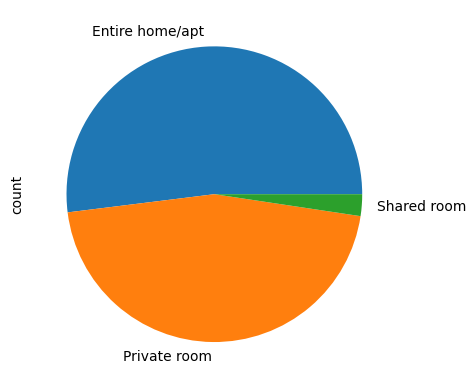

In [7]:
AB_NYC["room_type"].value_counts().plot(kind = 'pie')

<Axes: ylabel='count'>

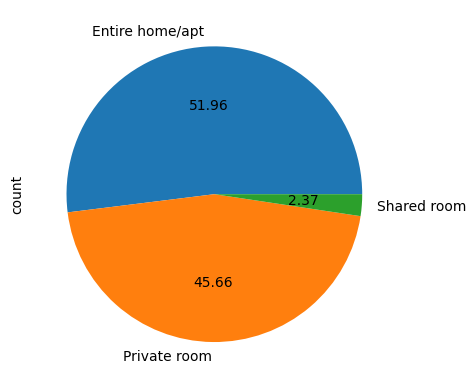

In [8]:
AB_NYC["room_type"].value_counts().plot(kind = "pie", autopct = "%.2f")

<Axes: ylabel='count'>

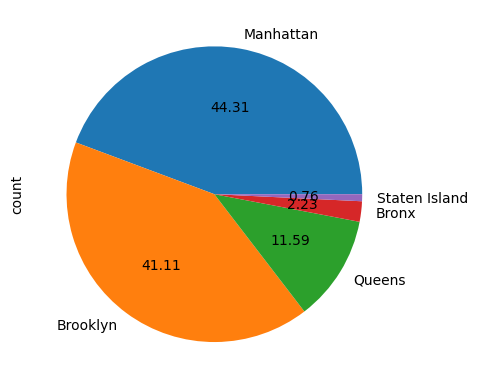

In [9]:
AB_NYC["neighbourhood_group"].value_counts().plot(kind="pie", autopct="%.2f")

# **Numerical Data**
Univariate analysis for numerical data is key to understanding the distribution and spread of values within a dataset. This type of analysis helps us visualize how data is distributed across different numerical features.

1. **Measures of Central Tendency:** mean, median, mode
2. **Measures of Dispersion:** variance, standard deviation, range, quartiles
3. **Visualization:** histograms, boxplots, density plots

- **Histograms** help visualize the frequency distribution of numerical data.
- **Distplots** provide a smoothed version of the histogram and show the probability distribution.
- **Box Plots** highlight the spread and identify outliers in the data.
- **Violin Plots** combine the features of both box plots and density plots for a more detailed view of the distribution.

## 1. Histogram
A histogram is used to visualize the distribution of numerical data by grouping values into bins. Each bin represents a range of values, and the height of the bar in each bin represents the frequency of values within that range.

<Axes: xlabel='price', ylabel='Count'>

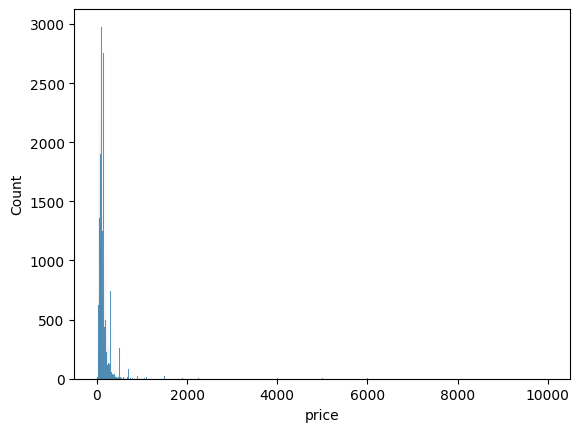

In [10]:
sns.histplot(data= AB_NYC, x="price")

To better visualize we can filter the data to only include hotels with prices less than $500 (lower range of prices)

<Axes: xlabel='price', ylabel='Count'>

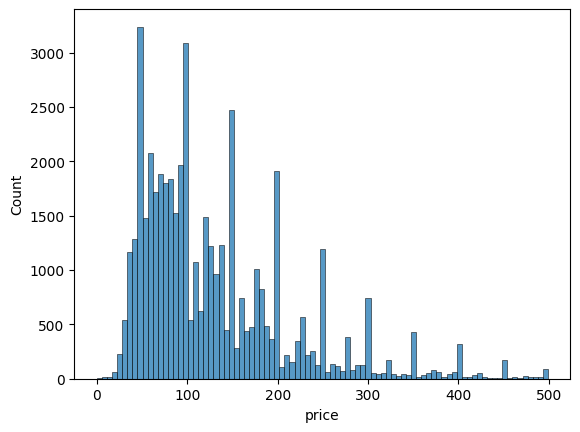

In [11]:
# Plotting a histogram for prices less than $500
sns.histplot(data= AB_NYC[AB_NYC['price']<500], x="price")

<Axes: xlabel='number_of_reviews', ylabel='Count'>

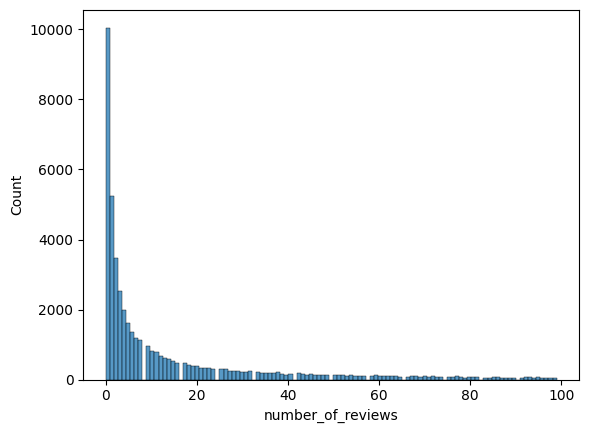

In [12]:
# Plotting a histogram for the 'number_of_reviews' column
sns.histplot(AB_NYC[AB_NYC["number_of_reviews"] < 100]["number_of_reviews"])

## Distplot: Visualizing Probability Distribution
 The distplot function provides a smoothed version of the histogram, also showing the probability distribution of the data. This can help us better understand the overall trend and skewness of the data.

/tmp/ipython-input-4160858507.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(AB_NYC["price"])


<Axes: xlabel='price', ylabel='Density'>

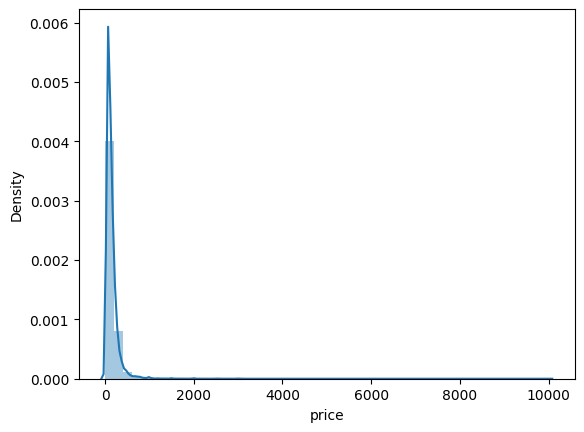

In [13]:
# Plotting a distplot for the 'price' column
sns.distplot(AB_NYC["price"])

In [14]:
# Binned value counts for the 'price' column
AB_NYC["price"].value_counts(bins=20)

,count
"(-10.001, 500.0]",47862
"(500.0, 1000.0]",805
"(1000.0, 1500.0]",100
"(1500.0, 2000.0]",53
"(2500.0, 3000.0]",21
"(2000.0, 2500.0]",20
"(3500.0, 4000.0]",11
"(4000.0, 4500.0]",6
"(4500.0, 5000.0]",6
"(9500.0, 10000.0]",6


## Box Plot: Identifying Outliers
A box plot is useful for visualizing the spread of the data, including the median, quartiles, and outliers. It helps us identify if there are extreme values (outliers) within a dataset.

<Axes: ylabel='price'>

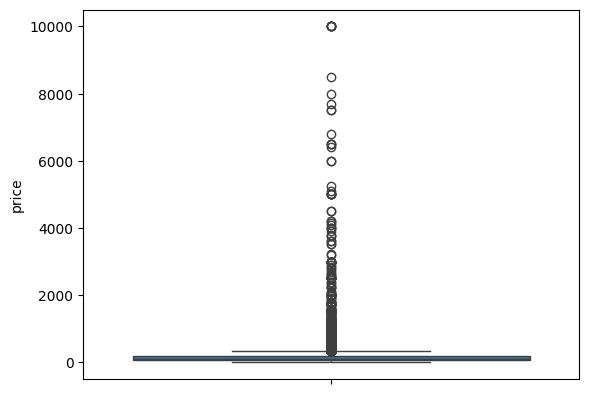

In [15]:
# Plotting a box plot for the 'price' column
sns.boxplot(AB_NYC["price"])

<Axes: ylabel='price'>

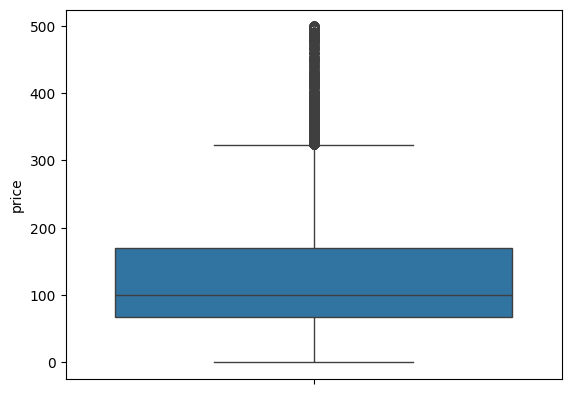

In [16]:
# Plotting a box plot for the 'price' column (Lower range of prices)
sns.boxplot(AB_NYC[AB_NYC["price"] < 500]["price"])

 the line within the box indicating the median, and the "whiskers" extending to the minimum and maximum values (excluding outliers). Any values outside the whiskers are considered outliers.

<Axes: ylabel='reviews_per_month'>

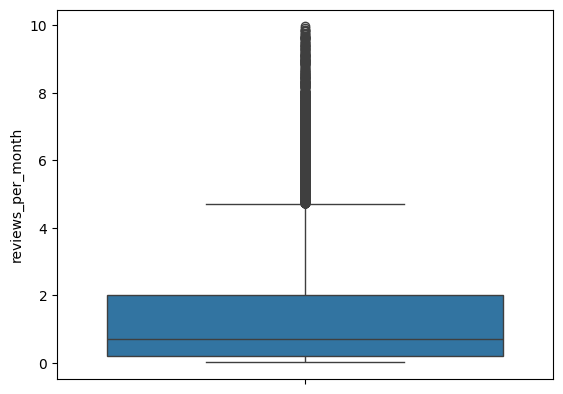

In [17]:
sns.boxplot(AB_NYC[AB_NYC["reviews_per_month"] < 10]["reviews_per_month"])

<Axes: ylabel='availability_365'>

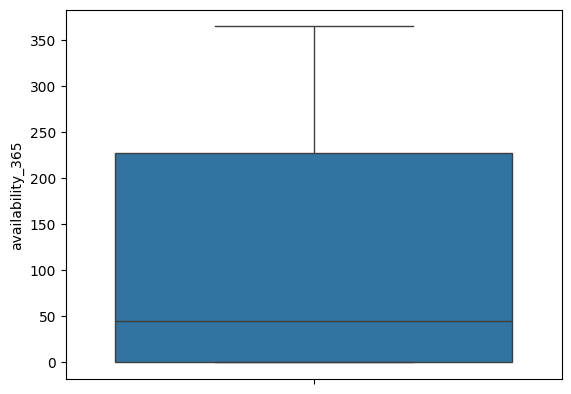

In [18]:
sns.boxplot(AB_NYC['availability_365'])

## Violin Plot: Combining Distribution and Box Plot
It shows the distribution of the data while also highlighting its density, providing a more comprehensive visualization of the distribution.

<Axes: ylabel='price'>

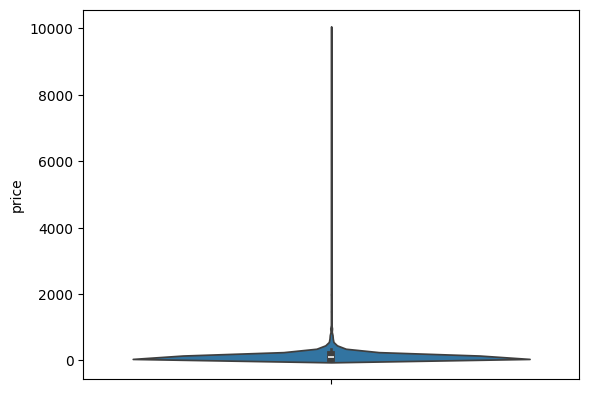

In [19]:
sns.violinplot(AB_NYC["price"])

<Axes: ylabel='price'>

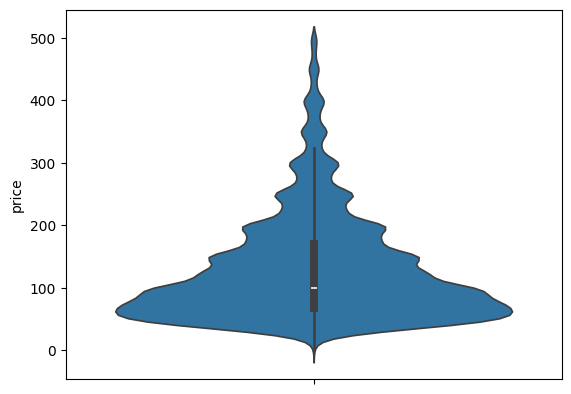

In [20]:
sns.violinplot(AB_NYC[AB_NYC["price"] < 500]["price"])

<Axes: ylabel='availability_365'>

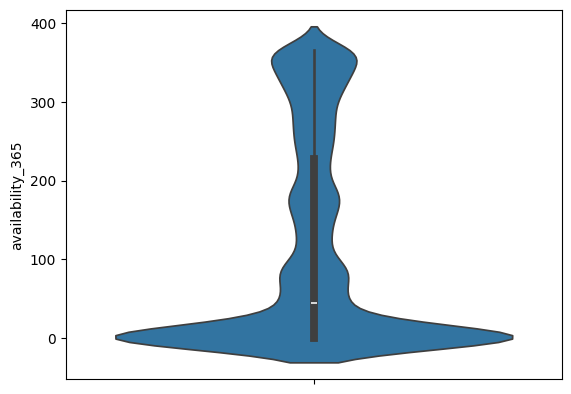

In [21]:
sns.violinplot(AB_NYC['availability_365'])

/tmp/ipython-input-2380419961.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(AB_NYC['availability_365'])


<Axes: xlabel='availability_365', ylabel='Density'>

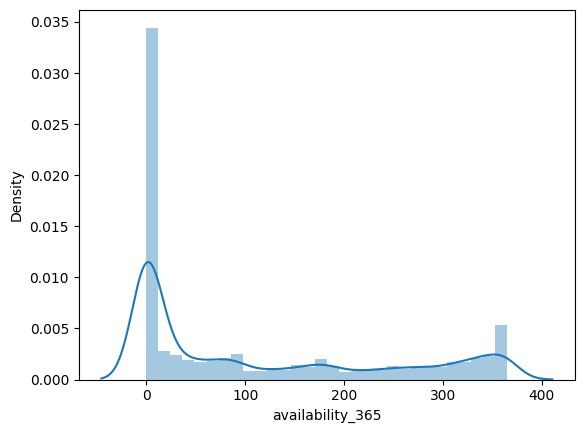

In [22]:
sns.distplot(AB_NYC['availability_365'])